In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [3]:
wid = 90
oversample = 4

nwavels_f110w = 20
nwavels_f160w = 20
nbasis_f110w = 10
nbasis_f160w = 5

n_zernikes = 20

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)

detector = NICMOSDetector(oversample, wid)

ddir = "../data/MAST_2024-09-22T03_37_01.724Z/HST/"

spectrum_basis_f110w = load_spectrum_basis("F110W", nwavels_f110w, nbasis_f110w)
spectrum_basis_f160w = load_spectrum_basis("F160W", nwavels_f160w, nbasis_f160w)


ddir = "../data/MAST_2024-09-26T22_53_13.719Z/HST/"

exposures_single = [
    exposure_from_file(ddir + "n8ry01tkq_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    #exposure_from_file(ddir + "n8ry01tmq_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    # exposure_from_file(ddir + "n8ry02tpq_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    # exposure_from_file(ddir + "n8ry02tqq_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),

    exposure_from_file(ddir + "n8ry03vbq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry03vcq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry04vfq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry04vgq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry05vmq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry05vnq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    ##exposure_from_file(ddir + "n8ry06vpq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry06vqq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
]


W0318 12:50:04.323594 36243882 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


207 60
207 60


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:159: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:159: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)


In [4]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

52947.50036751
HZ4
F110W
319.9581
52947.56708054
HZ4
F160W
319.9581


In [5]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 80.,
    "quadrature": {},
}


for idx, exp in enumerate(exposures_single):
    npoly = nbasis_f110w if exp.filter == "F110W" else nbasis_f160w
    nwavels = nwavels_f110w if exp.filter == "F110W" else nwavels_f160w
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set(np.log10(np.nansum(exp.data)/nwavels))
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.#-0.233#2.4#800.#160.*20
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

18.79822768839164
10.395854625938727


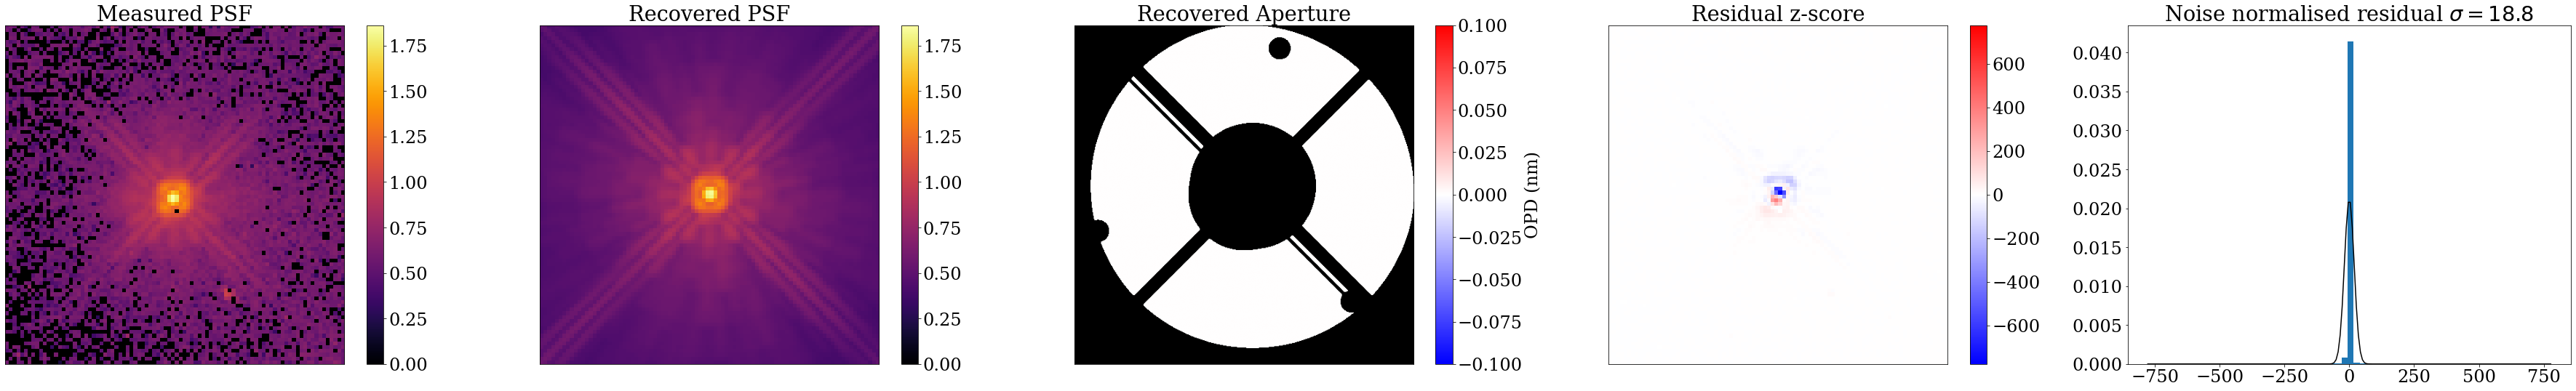

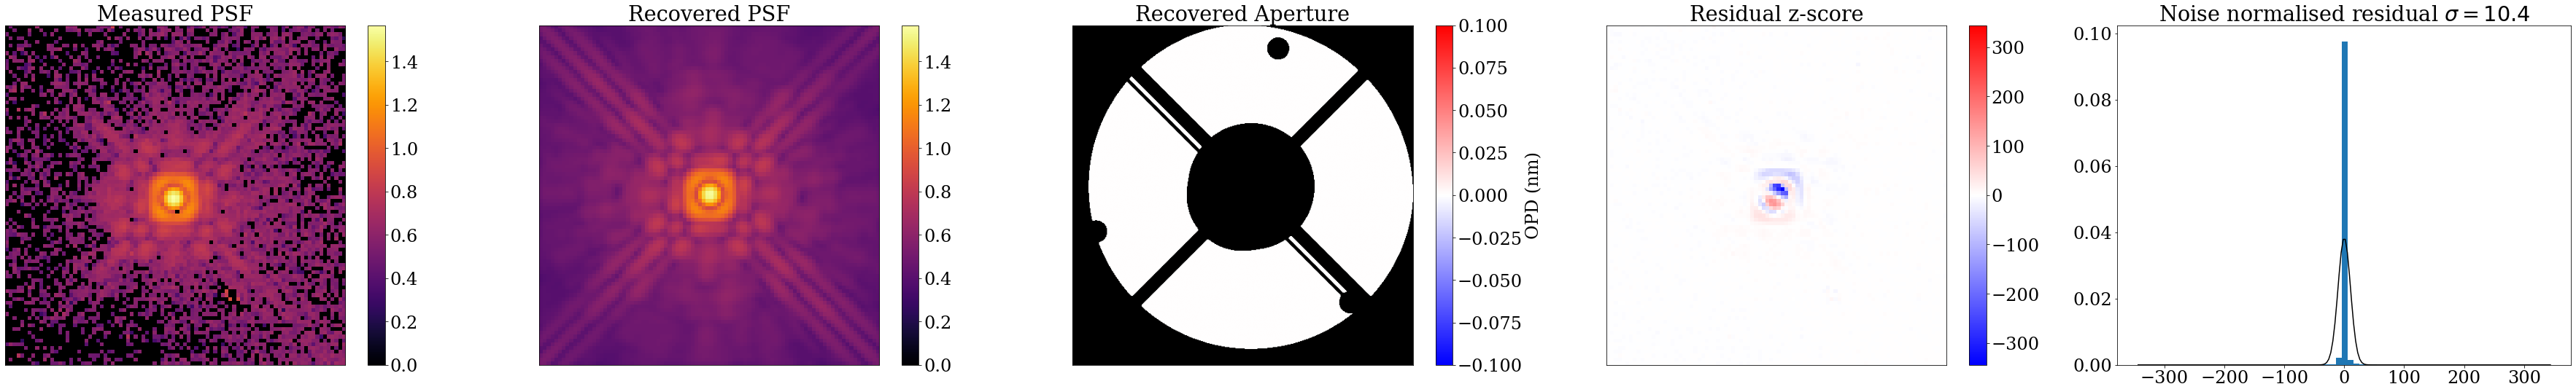

In [6]:
plot_comparison(model_single, params, exposures_single)

In [7]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*1, 10),
    "cold_mask_shift": sgd(g*1, 30),
    
    "bias": sgd(g*3, 20),
    "aberrations": sgd(g*1, 70),
    #"jitter": sgd(g*1, 120),

    "defocus": sgd(g*5, 30),
    #"fnumber": sgd(g*100, 100),
    "cold_mask_shear": sgd(g*0.5, 100),
    "quadrature": sgd(g*10, 400),
}


things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [8]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [9]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

[3.40703468e-07 2.91110757e-07 1.15154654e-06 8.48390105e-07]


  0%|          | 0/10 [00:00<?, ?it/s]

3.4325896242819565
2.1152914999399224


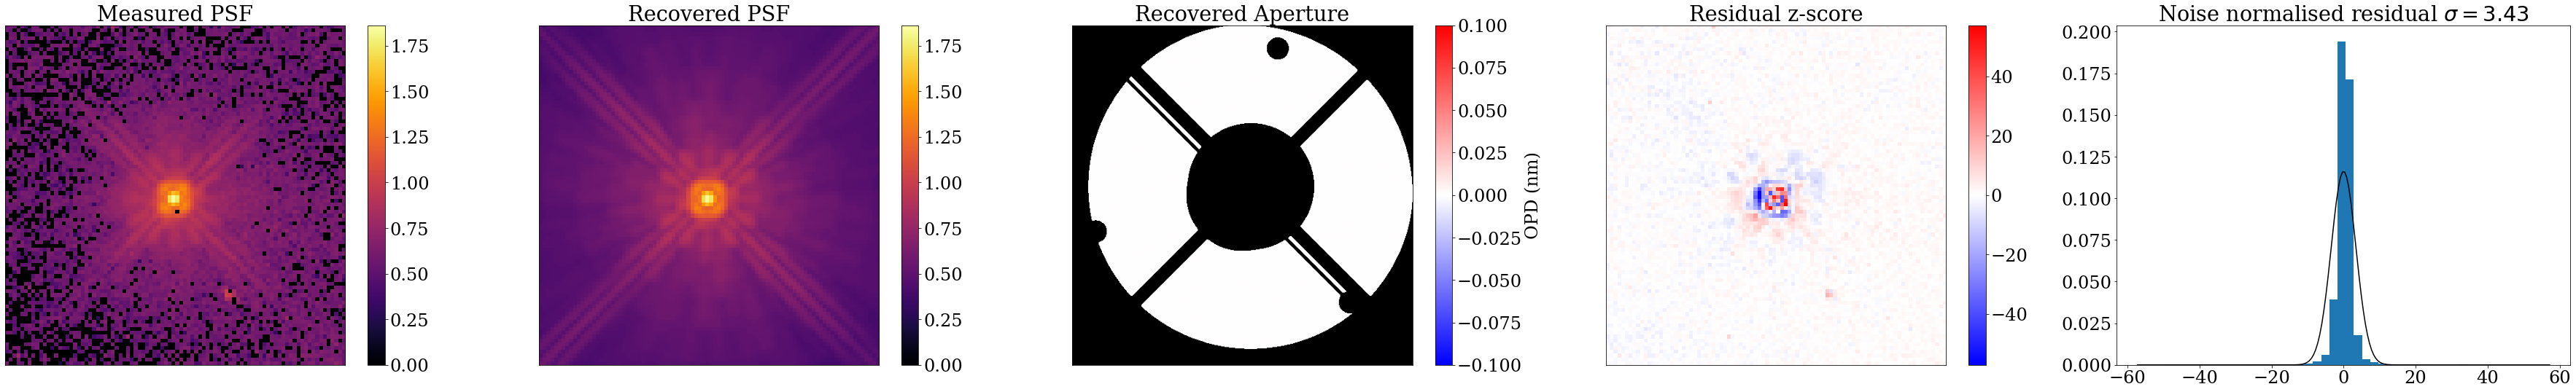

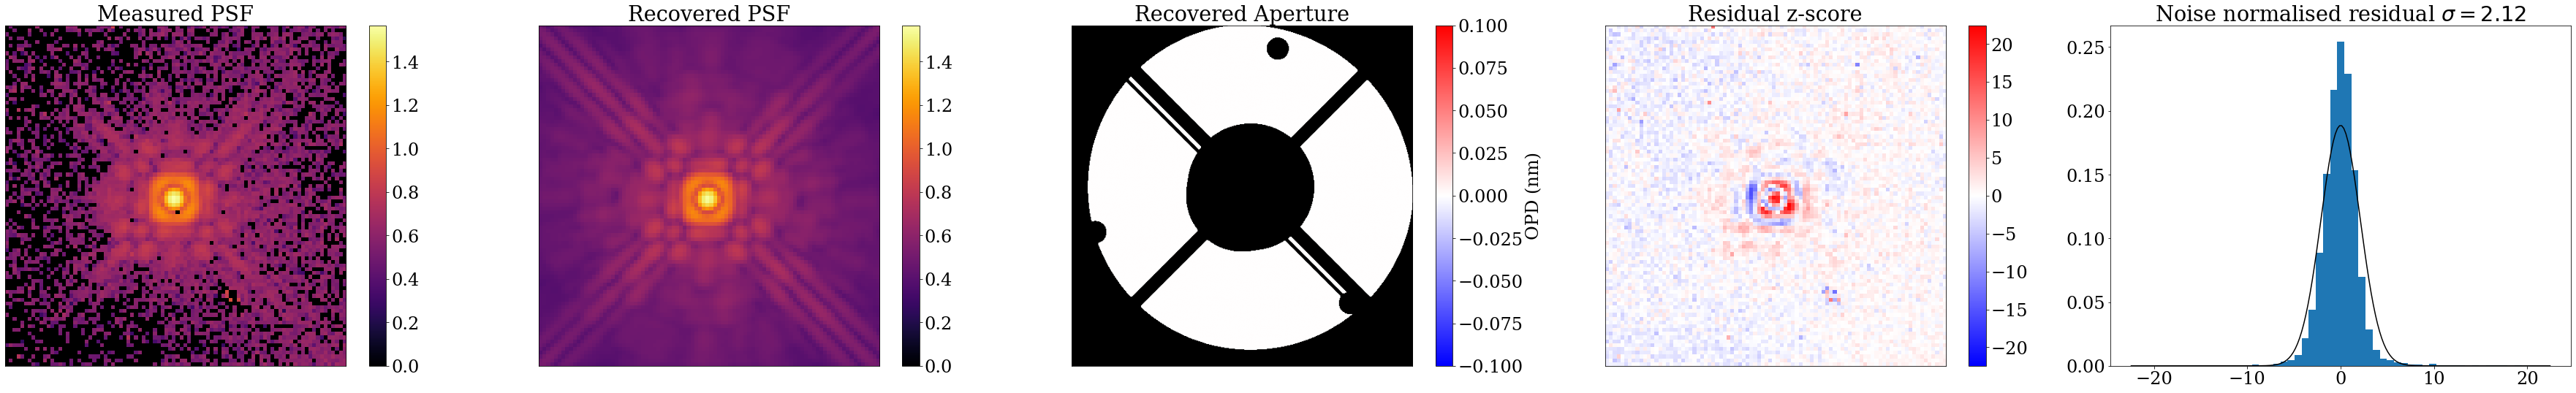

In [10]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False)

In [11]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [12]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 500, nbatches=5*len(exposures_single))

[5.65058908e-01 1.06013632e-01 9.95257313e-03 1.12920040e-02
 6.72656330e-03 7.01548718e-03 5.35950997e-02 3.20108669e-02
 7.95343338e-02 5.58739853e-02 4.25814006e-02 1.67236331e-02
 1.55095757e-02 7.86958542e-03 7.67360495e-03 1.56981515e-02
 1.60423273e-02 1.05999172e-01 1.23354910e-01 4.92831627e-02
 9.53763133e+00 1.26308593e+00 4.95645088e-02 5.12980297e-02
 3.33011538e-02 3.37652252e-02 2.58492895e-01 1.91523577e-01
 3.86938350e-01 3.02505459e-01 2.47772817e-01 7.71851210e-02
 7.61164366e-02 3.61559875e-02 3.57984863e-02 7.37095961e-02
 7.38798367e-02 6.64031724e-01 5.54681449e-01 3.69688825e-01
 1.24933992e-08 1.20282907e-08 5.65826433e-04 5.39096070e-04
 1.05248667e-03 1.13639798e-03 3.66568890e-05 2.06153138e-04
 5.10215603e-07 5.62333920e-07 1.81579976e-06 1.90825826e-06
 9.84301141e-07 2.60581910e-06 8.28416568e-08 6.41277929e-07
 1.45911405e-06 2.47088980e-06 4.61492213e-06 4.79061078e-06
 3.96392024e-06 3.93120819e-06 3.64325850e-06 3.45933902e-06
 2.10970568e-07 8.710031

  0%|          | 0/500 [00:00<?, ?it/s]

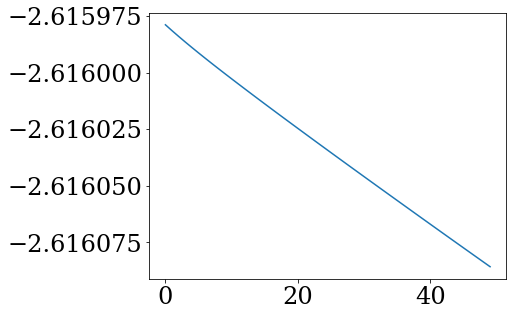

In [13]:
plt.plot(np.asarray(losses[-50:])/(len(exposures_single)*wid**2))

In [14]:
params_history_relative = [jax.tree.map(lambda x, y: x-y, x, params_history[0]) for x in params_history]

8
0.9987475718986626
0.9978838590265711


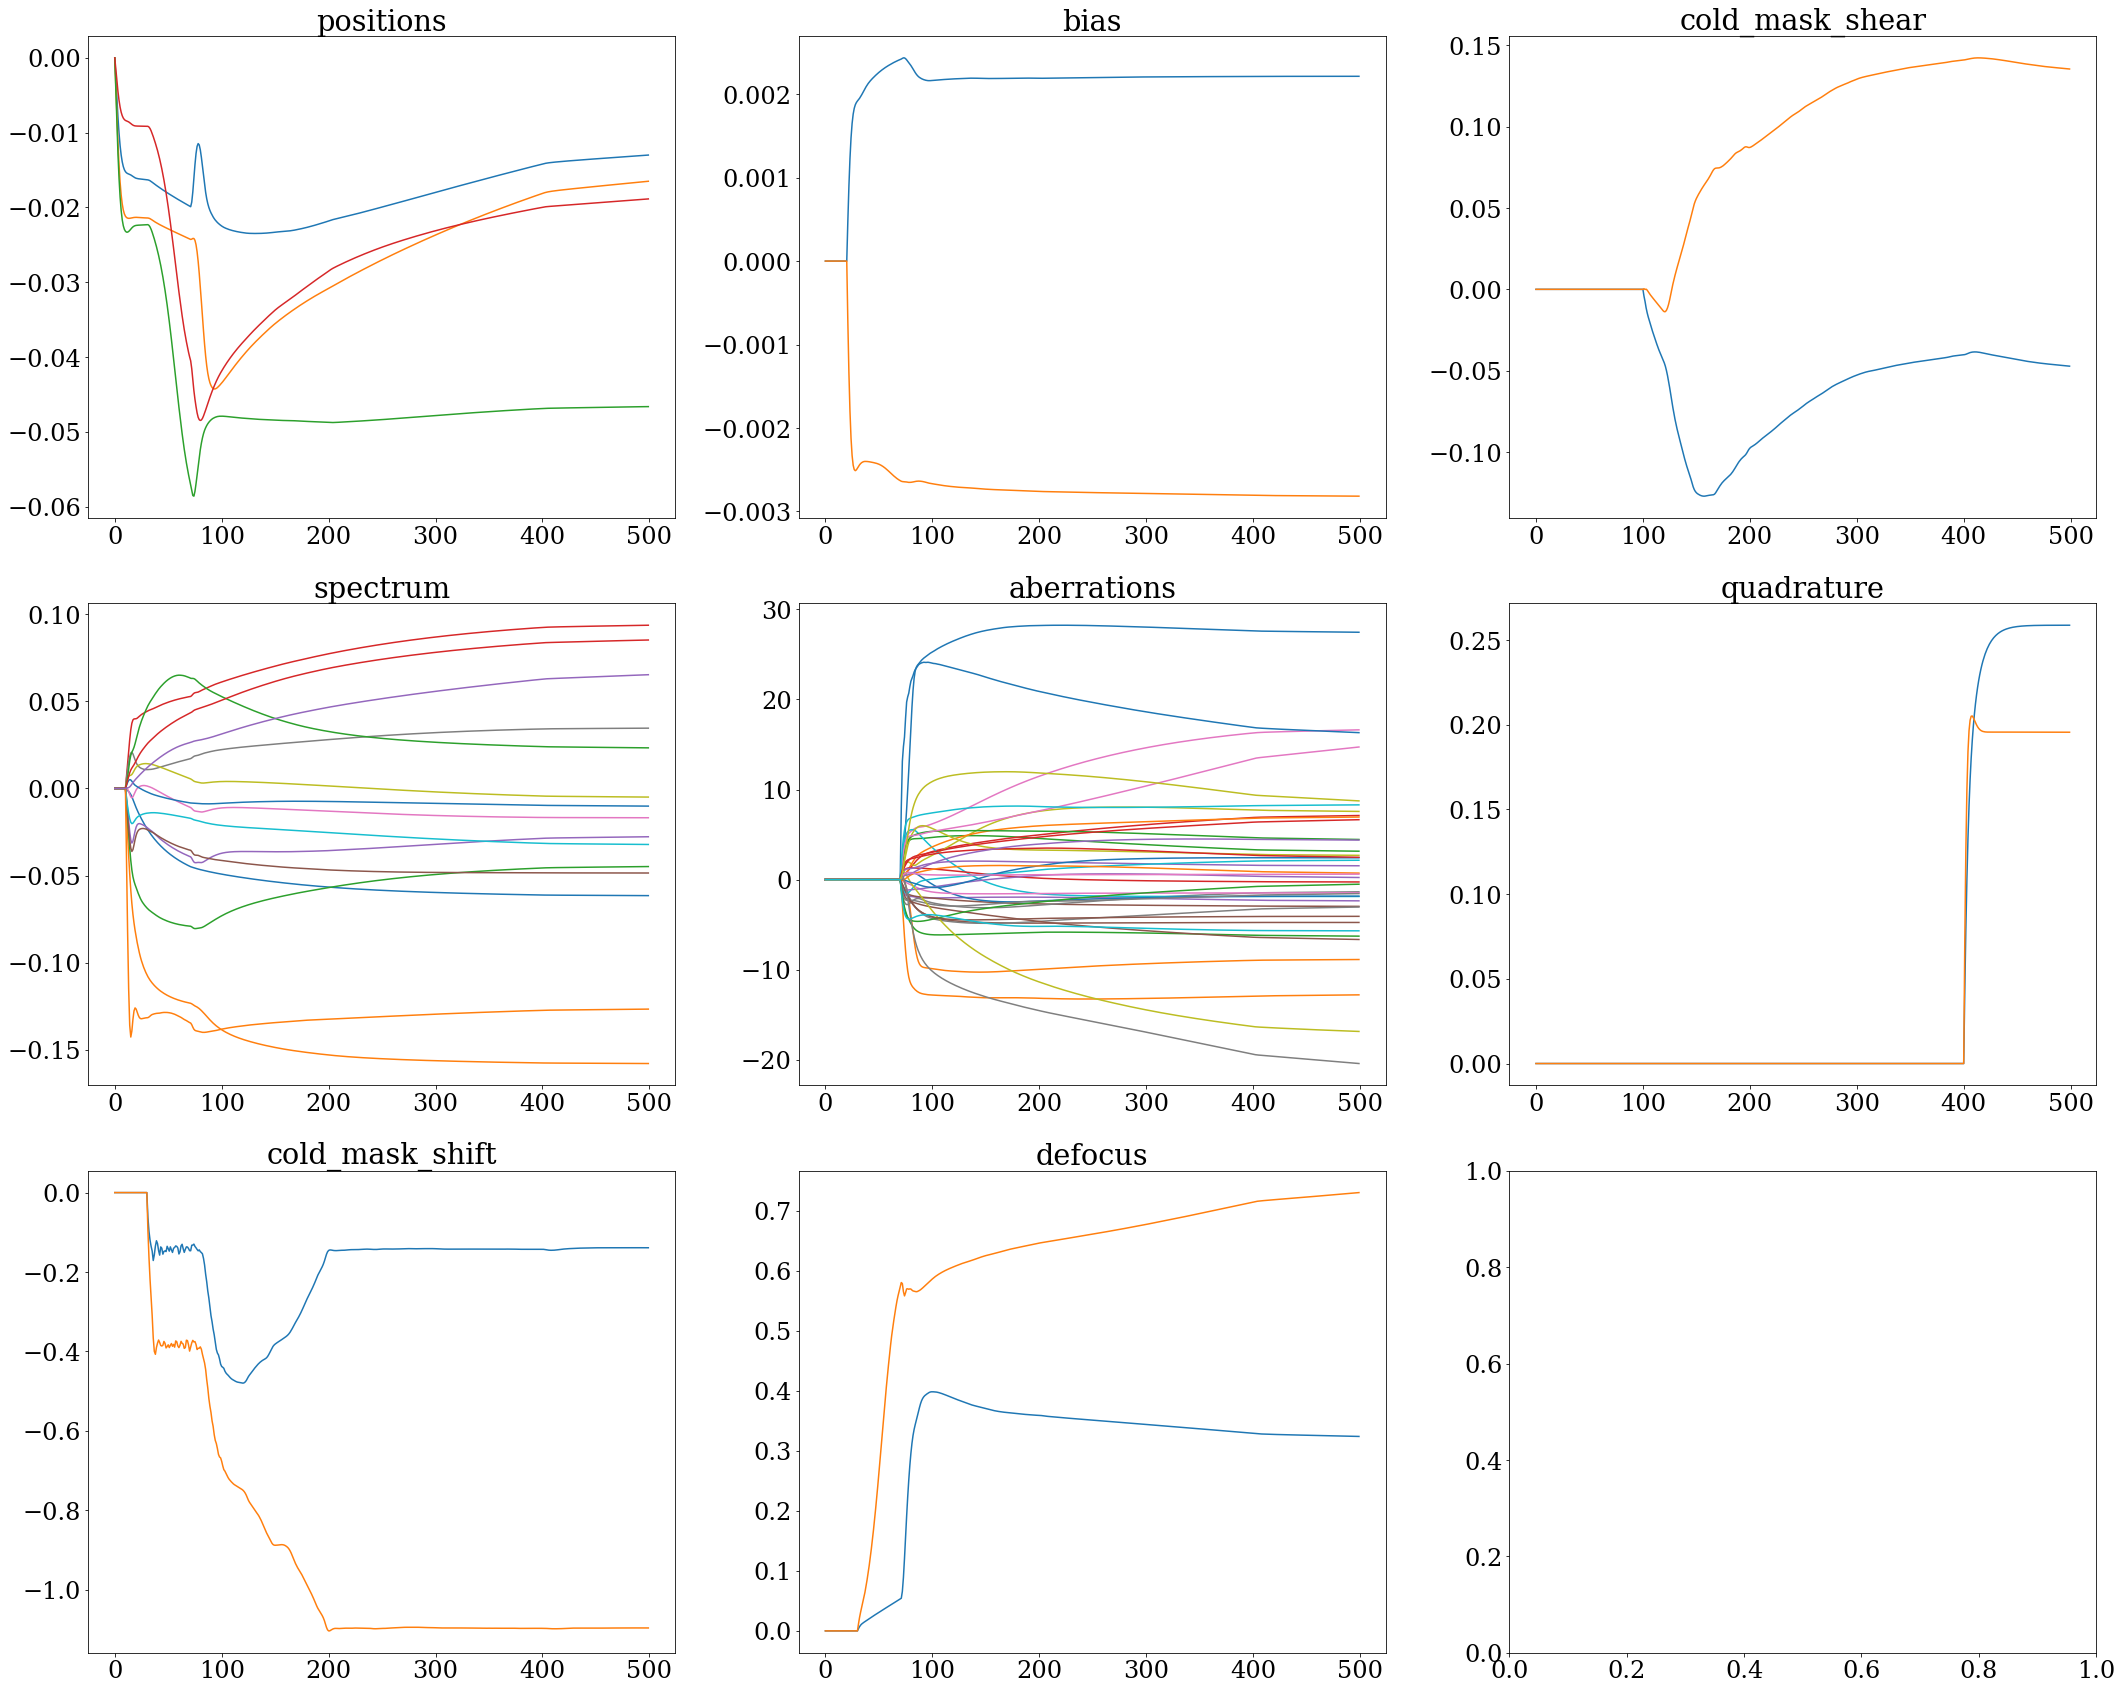

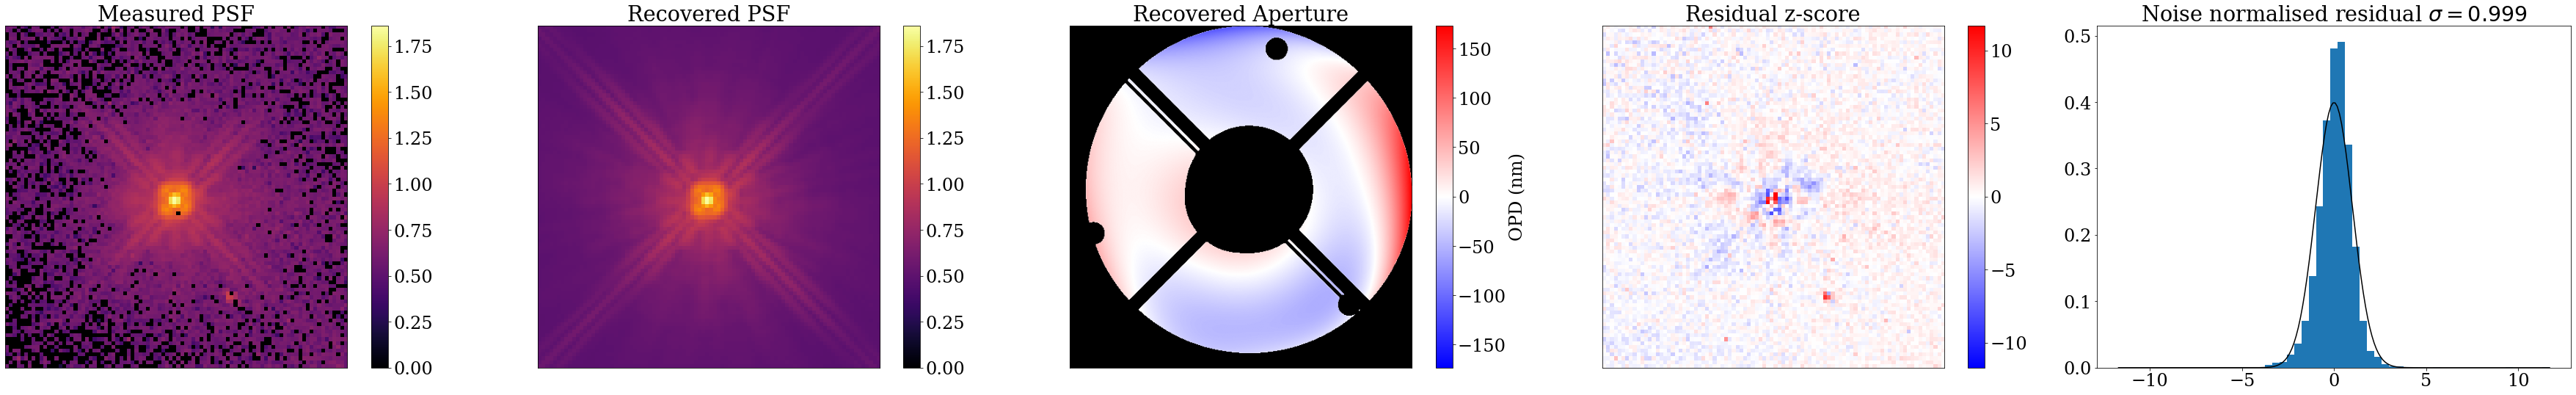

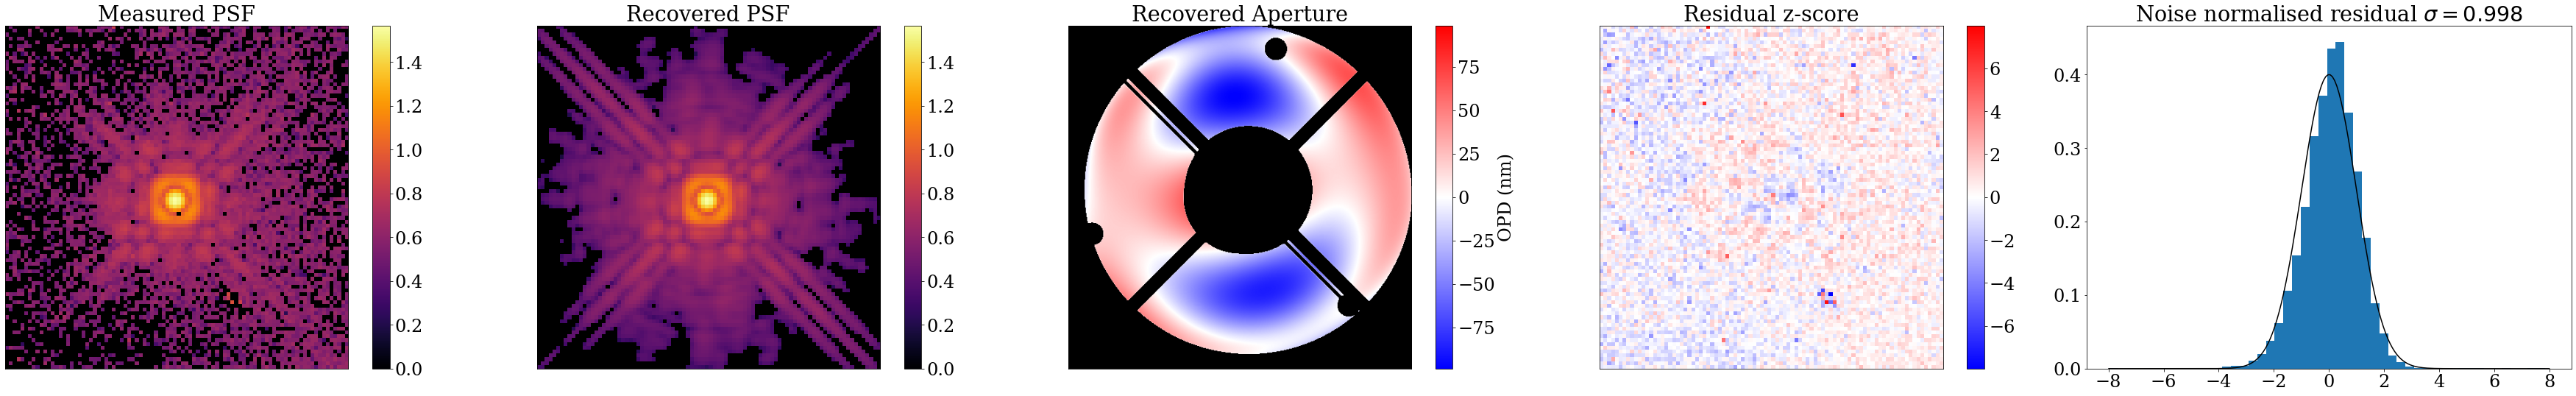

In [15]:
plot_params(params_history_relative, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [40]:
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single, project=True, diag=True)

In [41]:
final_params.params

{'aberrations': {'n8ry01tkq': Array([25.11523834, -9.04815108, -0.46117134,  9.94014389, -2.88988947,
         -3.65921542, 18.683711  , -1.23672116,  5.13761236, -1.85254626,
         -1.60763925,  9.77991068, -9.734902  , -0.79483266,  1.2502973 ,
         -4.63616368, -1.38718784,  5.15384846,  1.91903621,  2.60365208],      dtype=float64),
  'n8ry03vbq': Array([ 2.52574530e+01, -1.18120467e+01,  3.41040135e+00,  9.68352667e+00,
         -1.11878436e+00, -6.35102764e+00,  4.80763564e+01,  5.11209982e-02,
          3.28391618e+00, -3.28773493e+00,  8.09545588e-02, -1.28895996e-02,
          5.90351687e+00, -1.36756601e-01,  1.51820234e+00, -4.35383707e+00,
          6.55465276e-01, -3.54873765e+01, -1.25311553e+00, -2.23103124e+00],      dtype=float64)},
 'bias': {'n8ry01tkq': Array(0.00218052, dtype=float64),
  'n8ry03vbq': Array(-0.00323997, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.01269993,  0.16583103], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.023

In [42]:
#sol.stats

0.9987694374984095
0.9979509956254318


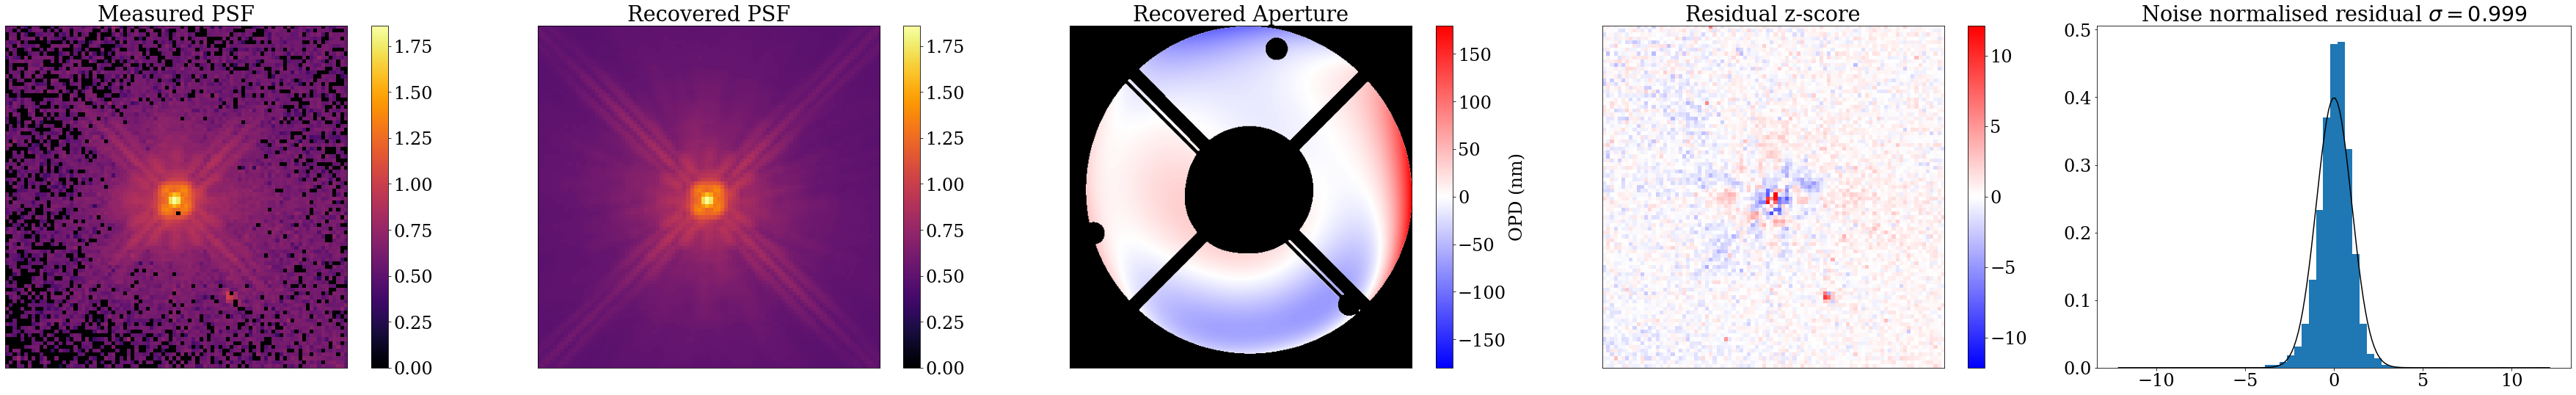

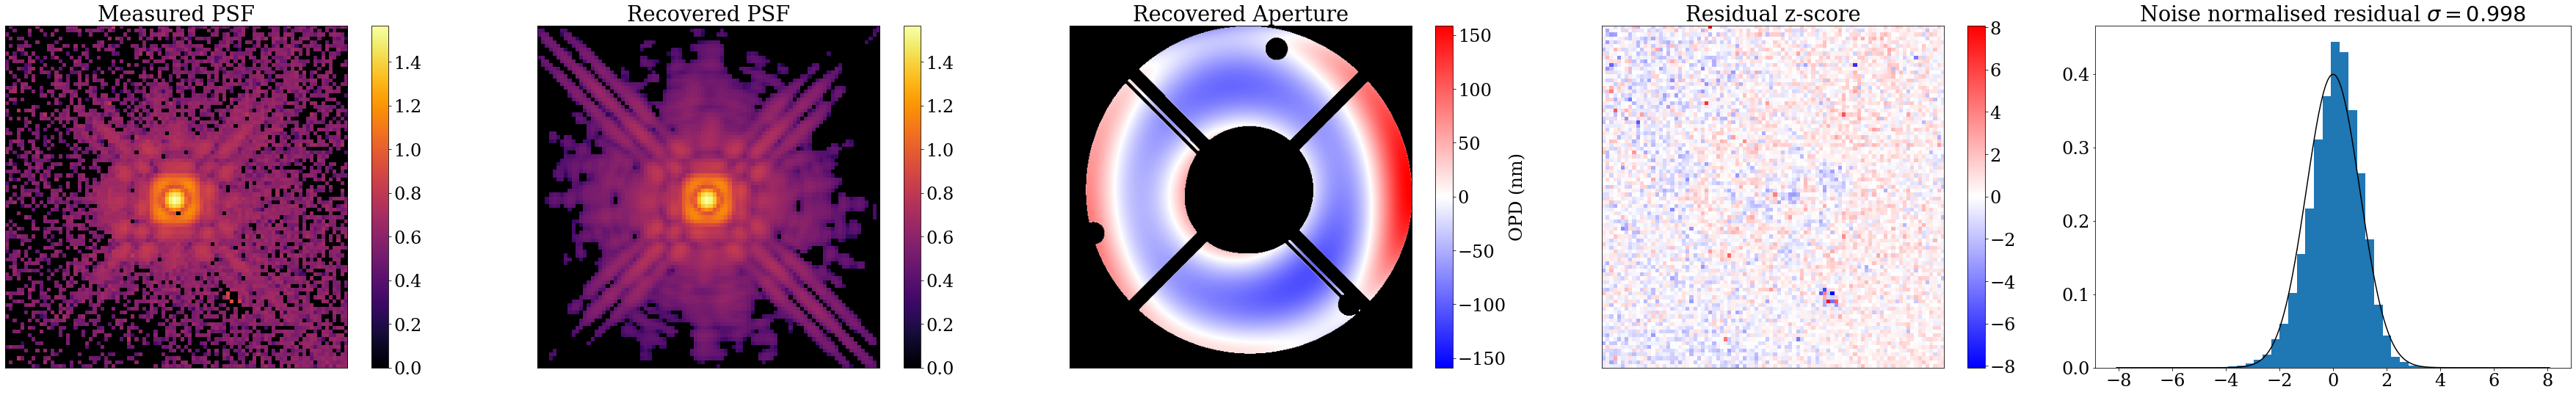

In [43]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single, quadrature=True)

In [44]:
# calculate spectrum

In [45]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [46]:
f = lambda params: loss_fn(ModelParams(params), exposures_single, final_params.inject((model_single)))
F, unflatten = zdx.batching.hessian(f, {"spectrum":final_params["spectrum"]}, nbatches=2)

In [47]:
cov_all = np.linalg.inv(F)
cov_f110w = cov_all[:nbasis_f110w, :nbasis_f110w]
cov_f160w = cov_all[nbasis_f110w:, nbasis_f110w:]

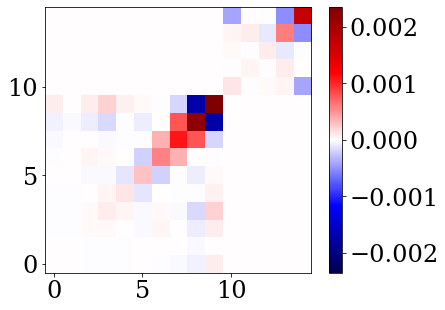

In [48]:
plt.imshow(np.linalg.inv(F), cmap='seismic', vmin=-np.max(np.abs(cov_all)), vmax=np.max(np.abs(cov_all)))
plt.colorbar()


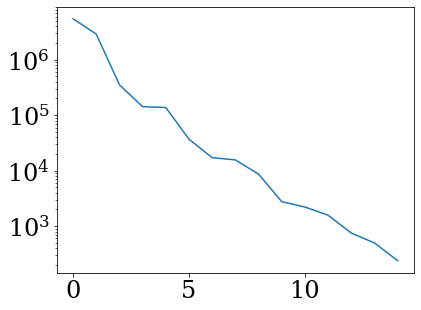

In [49]:
vals, vects = np.linalg.eig(F)#+fsh['n8yj02wyq.spectrum'])

order = np.argsort(vals)[::-1]

#plt.figure(figsize=(10,10))
#plt.xlabel("Coefficient")

#for i in range(5):
#    plt.plot(np.arange(npoly),np.real(vects[:,order[i]]), label=f"{i}")
#plt.legend()

plt.semilogy(np.sort(np.real(vals))[::-1])

In [50]:
#spec.filt_weights.sum()
#spec2.filt_weights.sum()

In [51]:
#(filt/(wv*1e6)).sum()/(filt2/(wv*1e6)).sum()

Text(0.5, 0, 'Wavelength (um)')

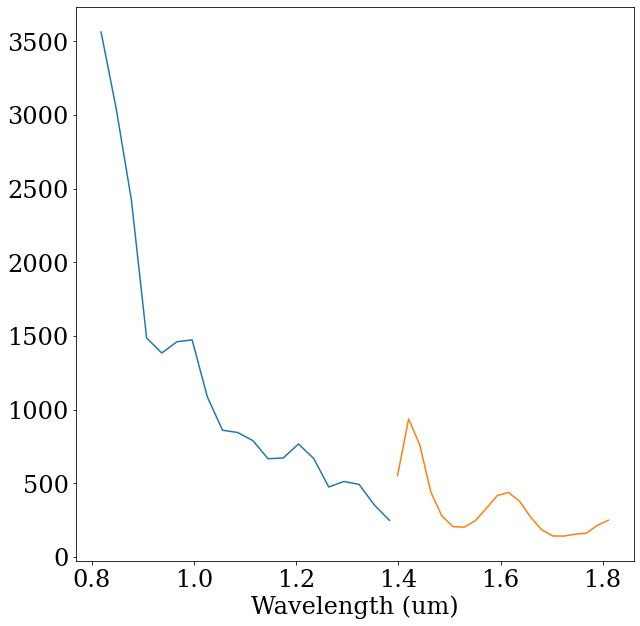

In [52]:
plt.figure(figsize=(10,10))

wv, filt = calc_throughput("F110W", nwavels=nwavels_f110w)

spec = CombinedBasisSpectrum(wv, filt, final_params.get("spectrum.HZ4_F110W"), spectrum_basis_f110w)

wv2, filt2 = calc_throughput("F160W", nwavels=nwavels_f160w)

spec2 = CombinedBasisSpectrum(wv2, filt2, final_params.get("spectrum.HZ4_F160W"), spectrum_basis_f160w)


sp = spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6)
sp2 = spec2.spec_weights()/spec2.flux*spec2.proper_flux()/(wv2*1e6)

#plt.plot(wavels, params.get("spectrum.U10764_F110W"))
plt.plot(wv*1e6, sp)
plt.plot(wv2*1e6, sp2)

plt.xlabel("Wavelength (um)")


In [53]:
from scipy.optimize import curve_fit
from scipy.constants import h, c, k

def planck_wavelength(wav, T, scale, bg):
    """
    Planck's Law as a function of wavelength (m) and temperature (K).
    Returns intensity in arbitrary units with a scaling factor.
    """
    a = 2.0 * h * c**2
    b = h * c / (wav * k * T)
    intensity = scale * a / ( (wav**4) * (np.exp(b) - 1.0) ) + bg# * (wav/1e-6)
    return intensity

def rayleigh_jeans(wav, scale):#, bg):
    return scale/wav**4# + bg

In [54]:
wavels = np.concat((wv, wv2))
spectrum = np.concat((sp, sp2))

initial_guesses = [14500.0, 1e-12, 0.] 

# Perform the curve fit
popt, pcov = curve_fit(planck_wavelength, wavels, spectrum, p0=initial_guesses, maxfev=10000)
print(popt)


[ 6.89476739e+07  2.88781254e-09 -1.77426201e+02]


In [55]:
from jax.numpy import linalg as la
def nearestPD(A):
    """Find the nearest positive-definite matrix to input

    A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
    credits [2].

    [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd

    [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
    matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
    """

    B = (A + A.T) / 2
    _, s, V = la.svd(B)

    H = np.dot(V.T, np.dot(np.diag(s), V))

    A2 = (B + H) / 2

    A3 = (A2 + A2.T) / 2

    if isPD(A3):
        return A3

    spacing = np.spacing(la.norm(A))
    # The above is different from [1]. It appears that MATLAB's `chol` Cholesky
    # decomposition will accept matrixes with exactly 0-eigenvalue, whereas
    # Numpy's will not. So where [1] uses `eps(mineig)` (where `eps` is Matlab
    # for `np.spacing`), we use the above definition. CAVEAT: our `spacing`
    # will be much larger than [1]'s `eps(mineig)`, since `mineig` is usually on
    # the order of 1e-16, and `eps(1e-16)` is on the order of 1e-34, whereas
    # `spacing` will, for Gaussian random matrixes of small dimension, be on
    # othe order of 1e-16. In practice, both ways converge, as the unit test
    # below suggests.
    I = np.eye(A.shape[0])
    k = 1
    while not isPD(A3):
        mineig = np.min(np.real(la.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1

    return A3


def isPD(B):
    """Returns true when input is positive-definite, via Cholesky"""
    try:
        _ = la.cholesky(B)
        return True
    except la.LinAlgError:
        return False


In [56]:
popt

array([ 6.89476739e+07,  2.88781254e-09, -1.77426201e+02])

In [57]:
np.sqrt(pcov[0,0])

Array(1.16878189e+11, dtype=float64)

In [58]:
np.round(153.2, -2)

Array(200., dtype=float64, weak_type=True)

In [59]:
spectrum

Array([3563.15398178, 3042.06428754, 2421.69910092, 1486.61152834,
       1384.37504677, 1461.02282587, 1473.28723485, 1086.5557436 ,
        860.2531766 ,  844.43366431,  789.49008363,  666.57560464,
        671.45160211,  766.70997008,  669.17737167,  474.45506283,
        512.21021047,  492.16397191,  352.54218365,  247.91061098,
        552.31632553,  937.09774442,  761.01961098,  441.04584144,
        277.53235996,  205.54841412,  202.15339595,  245.09097297,
        329.58045203,  417.20312376,  437.36933581,  377.9984792 ,
        269.41679436,  183.69425987,  141.86234328,  141.45175382,
        154.35062519,  160.3091998 ,  213.61292507,  249.57080718],      dtype=float64)

In [60]:
planck_wavelength(wavels, *popt) - spectrum #+ popt[2]

Array([-7.28085391e+02, -5.12943911e+02, -1.58461305e+02,  5.44459767e+02,
        4.43066520e+02,  1.87072623e+02,  1.62311047e+01,  2.62233050e+02,
        3.63211765e+02,  2.67061437e+02,  2.21656848e+02,  2.54375312e+02,
        1.68203393e+02, -5.22042838e-01,  3.04521772e+01,  1.64731421e+02,
        7.19620149e+01,  4.18267358e+01,  1.35580524e+02,  1.98203921e+02,
       -1.27001316e+02, -5.39023884e+02, -3.88569755e+02, -9.27210860e+01,
        4.80581814e+01,  9.85999914e+01,  8.17544483e+01,  1.96948826e+01,
       -8.28742278e+01, -1.87604242e+02, -2.23969997e+02, -1.79950311e+02,
       -8.59262407e+01, -1.40183866e+01,  1.46949883e+01,  2.63987248e+00,
       -2.21119779e+01, -3.93479938e+01, -1.03388136e+02, -1.49573468e+02],      dtype=float64)

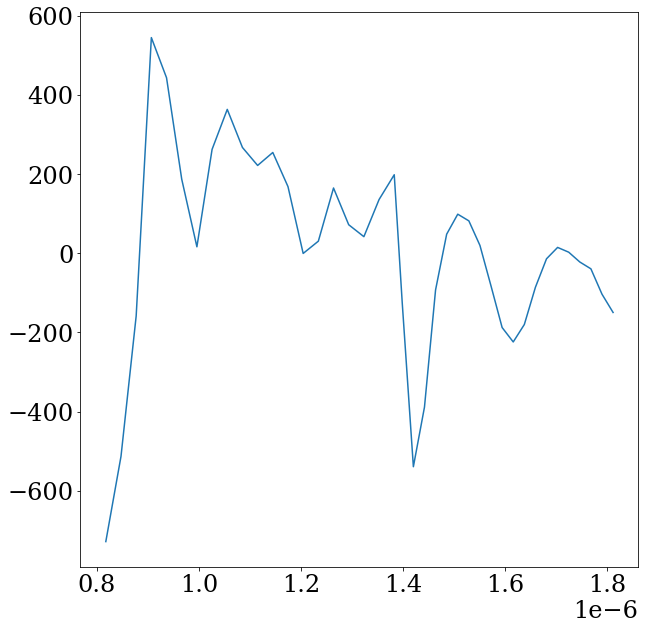

In [61]:
plt.figure(figsize=(10,10))
plt.plot(wavels, planck_wavelength(wavels, *popt) - spectrum)#+  popt[2])

Text(0.5, 0, 'Wavelength (um)')

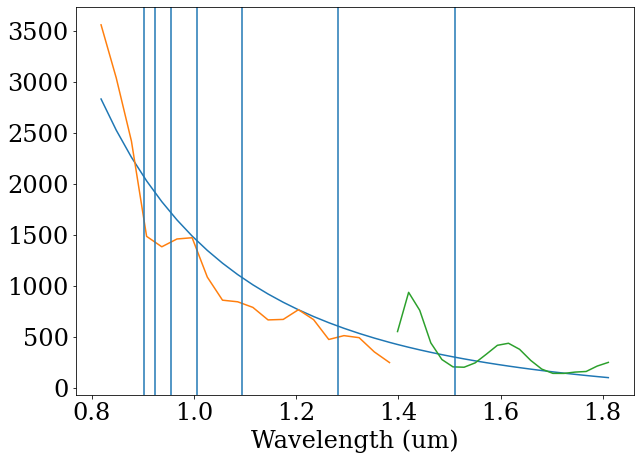

In [62]:
plt.figure(figsize=(10,7))

plt.plot(np.sort(wavels)*1e6, planck_wavelength(np.sort(wavels), *popt), label=fr"Blackbody Curve")# $T = {np.round(popt[0], -3):3.0f}$")
plt.plot(wv*1e6, sp, label = "F110W Spectrum")
plt.plot(wv2*1e6, sp2, label = "F160W Spectrum")

plt.axvline(1.282)
plt.axvline(1.094)
plt.axvline(0.9546)
plt.axvline(1.005)
plt.axvline(0.923)
plt.axvline(0.901)

plt.axvline(1.51)



plt.xlabel("Wavelength (um)")
#plt.legend()

Text(0.5, 0, 'Wavelength (um)')

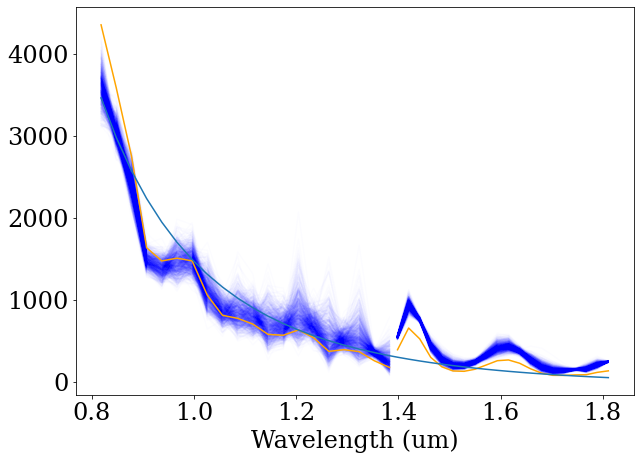

In [63]:
plt.figure(figsize=(10,7))

plt.plot(wv*1e6, sp/(wv*1e6), color='orange')
plt.plot(wv2*1e6, sp2/(wv2*1e6), color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.HZ4_F110W"), nearestPD(cov_f110w))
    spec = CombinedBasisSpectrum(wv, filt, coeffs, spectrum_basis_f110w)#CombinedFourierSpectrum(wv, filt, coeffs)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6), color='b', alpha=0.01, zorder=0)

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.HZ4_F160W"), nearestPD(cov_f160w))
    spec = CombinedBasisSpectrum(wv2, filt2, coeffs, spectrum_basis_f160w)#CombinedFourierSpectrum(wv, filt, coeffs)
    plt.plot(wv2*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv2*1e6), color='b', alpha=0.01, zorder=0)

plt.plot(wavels*1e6, planck_wavelength(wavels, *popt)/(wavels*1e6), label=fr"Blackbody Curve")# $T = {np.round(popt[0], -3):3.0f}$")


plt.xlabel("Wavelength (um)")
#plt.legend()